Characterizing Qubit Precession with IBM Hardware  (Arnav Jain)

For my Quantum Computing Research Project, I would like to complete and get an accurate answer for problem 2.6 (Bayesian estimation). I will be fitting the `IBM_dirp_raw.data` dataset using Bayesian Inference.

Firstly, I will import all the neccessary libraries and functions that will be used in the code. These are all the functions that we covered during the DiRP meeting.

**Imports**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import pickle
from scipy.special import logsumexp

**Important Functions**

In [ ]:
def plot_likelihood(ps, Ls, log):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    ax.set_title("Log-likelihood" if log else "Likelihood")
    ax.plot(ps, Ls, color="black")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Value of $p_1$")
    ax.set_ylabel("Likelihood")

    plt.show()

def mu_std(xs, ws, return_std, log):
    if log:
        logZ = logsumexp(ws)
        ws = np.exp(ws - logZ)
    else:
        ws = ws/np.sum(ws)

    mu = np.sum(ws * xs)
    std = np.sqrt(np.sum(ws * (xs - mu)**2))
    if return_std:
        return mu, std
    return mu

def likelihood(ws, ts, ys, eps = 1e-10):
    args = np.outer(ws, ts) / 2.0
    p1s = np.cos(args) ** 2
    p1s = np.clip(p1s, eps, 1 - eps)
    Ls = np.sum(ys*np.log(p1s) + (1 - ys)*np.log1p(-p1s), axis=1)
    return Ls

def bayesian_estimate(xs, ys, domain, Npoints = int(1e3), log = True, plot = False, std = False):
    ws = np.linspace(domain[0],domain[1], Npoints)
    Ls = likelihood(ws, xs, ys)
    if plot:
        plot_likelihood(ws, Ls, log)
    return mu_std(ws, Ls, std, log)

In [ ]:
def plot_data(ts, Ds, ref = None):
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    ax.set_title("Precession")
    if ref is not None:
      ax.plot(ts, ref, color="black", linestyle="--")
    else:
      ax.plot(ts, Ds, color="black", linestyle="--")

    ax.scatter(ts, Ds, marker="x",s=50, zorder = 2, linewidth=3.5, color="firebrick")

    ax.minorticks_on()
    ax.grid(which="major", linestyle="-", alpha=0.6)
    ax.grid(which="minor", linestyle=":", alpha=0.4)

    ax.set_xlabel("Time (t)")
    ax.set_ylabel("Fraction of + outcomes")

    plt.show()

In [ ]:
def prob(ts, w):
  return np.cos(w*ts/2)**2

**Reading the Data**

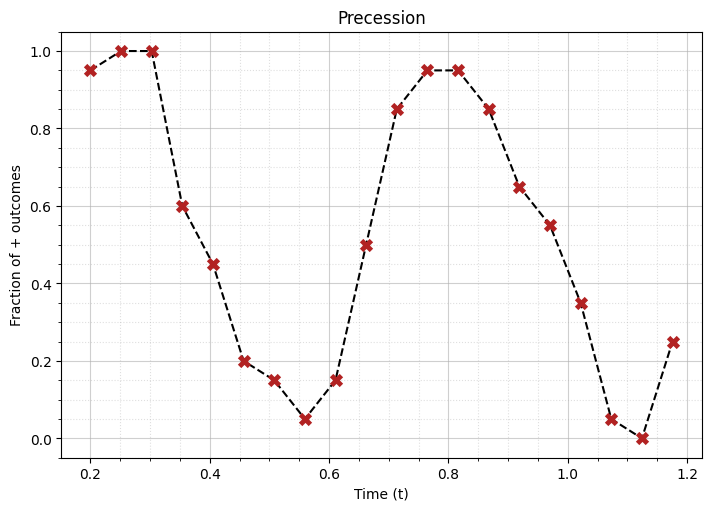

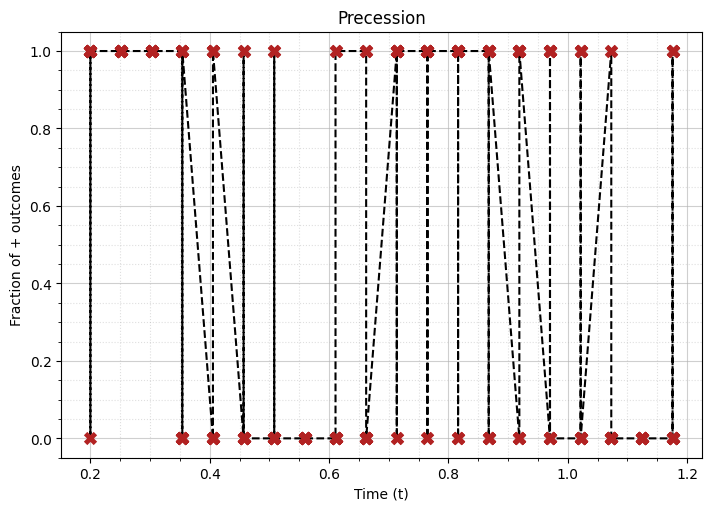

In [ ]:
with open('IBM_dirp_raw.data', 'rb') as filehandle:
    xs2, ys2 = pickle.load(filehandle)

with open('IBM_dirp.data', 'rb') as filehandle:
    xs, ys = pickle.load(filehandle)

plot_data(xs, ys)
plot_data(xs2, ys2)

**Likelihood and Initial Attemp**

I would like to first apply Bayesian inference to the raw IBM quantum hardware data.

Unlike curve fitting which we did during the meeting and operates on the averaged results, Bayesian inference
processes every individual shot (0 or 1).

I have defined the domain and calculated the likelihood for each.

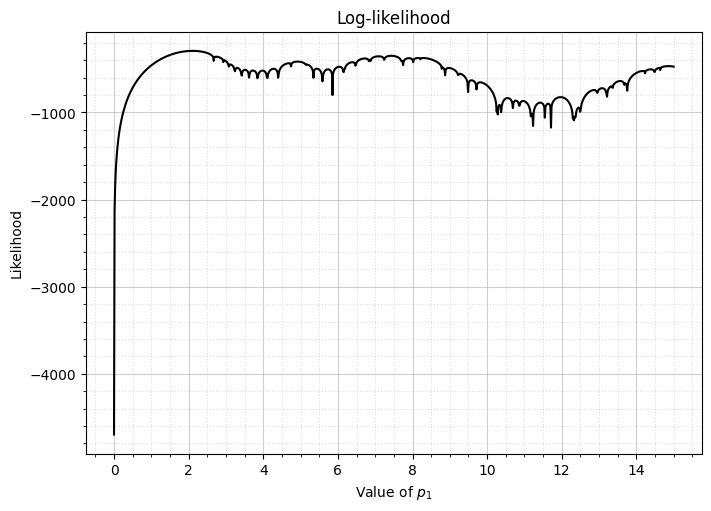

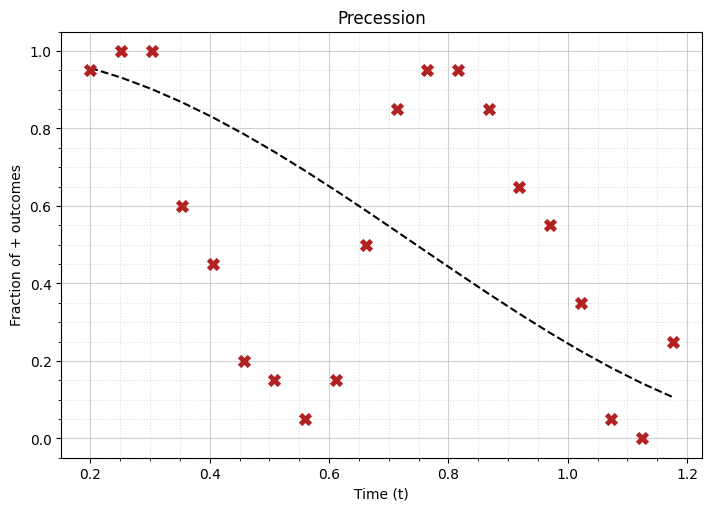

Bayesian inference on real data: estimated ω = 2.1062


In [ ]:
omega_domain = (0, 15)

w_bayesian = bayesian_estimate(xs2, ys2, domain=omega_domain, plot=True)
predictions = prob(xs, w_bayesian)
plot_data(xs, ys, ref=predictions)

print(f"Bayesian inference on real data: estimated ω = {w_bayesian:.4f}")

**Second Attempt**

Unfortunately, the previous Bayesian fit failed because the Likelihood function is 'multi-modal'. Taking the mean of all these peaks resulted in a poor fit.

Instead I now identified the 'Maximum Likelihood Estimate', which is the highest peak, and narrowed the search domain to where the data actually oscillates.


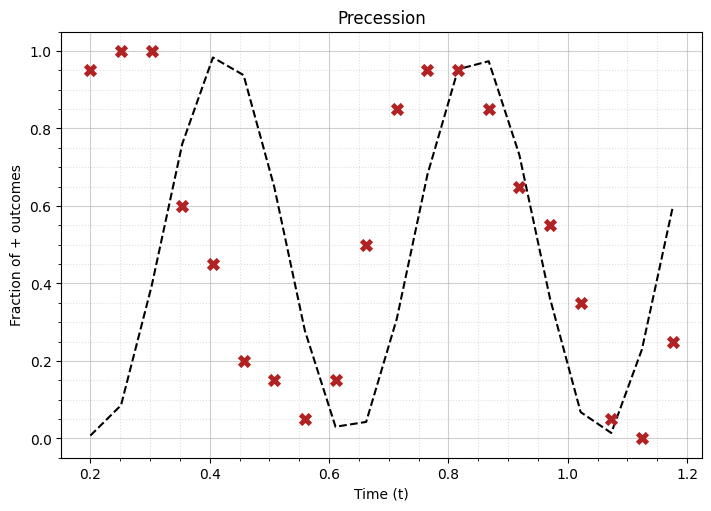

> Maximum Likelihood Estimate: ω = 14.8599


In [ ]:
omega_domain = (10, 15)

ws_fine = np.linspace(omega_domain[0], omega_domain[1], 1000)
Ls_fine = likelihood(ws_fine, xs2, ys2)

w_mle = ws_fine[np.argmax(Ls_fine)]

predictions_mle = prob(xs, w_mle)
plot_data(xs, ys, ref=predictions_mle)

print(f"> Maximum Likelihood Estimate: ω = {w_mle:.4f}")

**Third Attempt**

This result is good because it has found the correct frequency.

However, the model was out of phase with the real IBM data.

To fix this, I can perform a 2D Bayesian search. I will create a grid of possible frequencies and possible phase shifts. We then calculate the likelihood for every pair in the grid and pick the one that best fits the raw measurement outcomes.


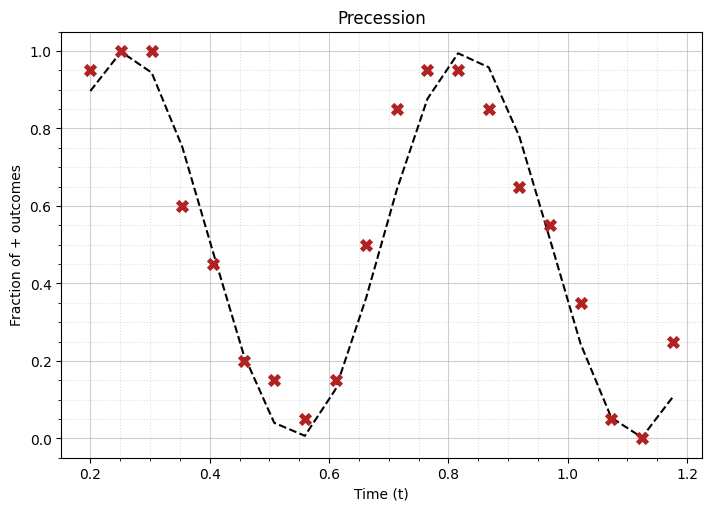

> Final Bayesian Estimate: ω = 11.0101, Phase B = 1.7136


In [ ]:
omega_range = np.linspace(10, 15, 100)
phase_range = np.linspace(0, np.pi, 100)

def likelihood_2d(ws, bs, ts, ys, eps = 1e-10):
    args = (np.outer(ws, ts) / 2.0)[:, np.newaxis, :] + bs[np.newaxis, :, np.newaxis]
    p1s = np.cos(args) ** 2
    p1s = np.clip(p1s, eps, 1 - eps)

    Ls = np.sum(ys * np.log(p1s) + (1 - ys) * np.log1p(-p1s), axis=2)
    return Ls

Ls_grid = likelihood_2d(omega_range, phase_range, xs2, ys2)

w_idx, b_idx = np.unravel_index(np.argmax(Ls_grid), Ls_grid.shape)
best_w = omega_range[w_idx]
best_b = phase_range[b_idx]

def prob_with_phase(ts, w, b):
    return np.cos(w * ts / 2 + b) ** 2

predictions_final = prob_with_phase(xs, best_w, best_b)
plot_data(xs, ys, ref=predictions_final)

print(f"> Final Bayesian Estimate: ω = {best_w:.4f}, Phase B = {best_b:.4f}")

This solves the problem!

I upgraded the physics model to account for the "starting position" of the qubit.

Additionally, instead of guessing if B should be pi/2 or 0, we let the Bayesian Likelihood "vote" on which combination of omega and B explains the data best.

We also have high robustness. Even if the data were noisy, this 2D peak-finding method was able to reliably find ways to characterize the qubit.